# Dog vs Cat Classification using CNN
This notebook is converted from the uploaded Python script. Each major step is placed in a separate cell.

In [16]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import kagglehub
import os
import cv2

In [17]:
# Download dataset
path = kagglehub.dataset_download("bhavikjikadara/dog-and-cat-classification-dataset")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\rajpu\.cache\kagglehub\datasets\bhavikjikadara\dog-and-cat-classification-dataset\versions\1


In [18]:
# Explore dataset
print(os.listdir(path))

petimage_data = os.path.join(path, "PetImages")
print(os.listdir(petimage_data))

dog_image = os.path.join(path, "PetImages/Dog")
cat_image = os.path.join(path, "PetImages/Cat")

print("Number of Dog Images:", len(os.listdir(dog_image)))
print("Number of Cat Images:", len(os.listdir(cat_image)))
print(os.listdir(dog_image)[:10])

['PetImages']
['Cat', 'Dog']
Number of Dog Images: 12499
Number of Cat Images: 12499
['0.jpg', '1.jpg', '10.jpg', '100.jpg', '1000.jpg', '10000.jpg', '10001.jpg', '10002.jpg', '10003.jpg', '10004.jpg']


In [19]:
# Read a sample image
image_file_name = os.listdir(dog_image)[0]
img_path = os.path.join(dog_image, image_file_name)
img = cv2.imread(img_path)
print(img.shape)

(375, 500, 3)


In [20]:
# Initialize lists
X = []
Y = []

In [21]:
# Load Dog Images
for image_name in os.listdir(dog_image)[:5000]:
    image_path = os.path.join(dog_image, image_name)
    img = cv2.imread(image_path)

    if img is None:
        print("Cannot read:", image_name)
        continue

    img = cv2.resize(img, (128, 128))
    img = img.astype(np.float32) / 255.0
    X.append(img)
    Y.append(1)

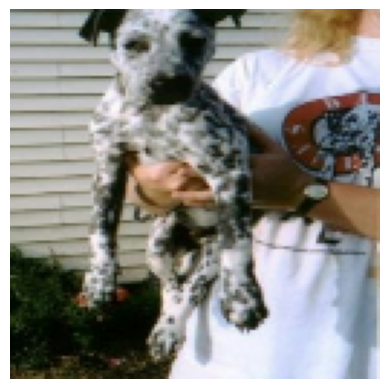

In [22]:
# Display a sample dog image
image_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(image_rgb)
plt.axis("off")
plt.show()

In [23]:
# Load Cat Images
for image_name in os.listdir(cat_image)[:5000]:
    image_path = os.path.join(cat_image, image_name)
    img2 = cv2.imread(image_path)

    if img2 is None:
        print("Cannot read:", image_name)
        continue

    img2 = cv2.resize(img2, (128, 128))
    img2 = img2.astype(np.float32) / 255.0
    X.append(img2)
    Y.append(0)

Cannot read: 10404.jpg


In [25]:
# Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

X_train = np.array(X_train)
X_test = np.array(X_test)
Y_train = np.array(Y_train)
Y_test = np.array(Y_test)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of Y_train:", Y_train.shape)
print("Shape of Y_test:", Y_test.shape)

Shape of X_train: (7999, 128, 128, 3)
Shape of X_test: (2000, 128, 128, 3)
Shape of Y_train: (7999,)
Shape of Y_test: (2000,)


In [26]:
# Build CNN Model
model = keras.Sequential([
    layers.Conv2D(32, kernel_size=(3,3), activation="relu", input_shape=(128,128,3)),
    layers.MaxPooling2D(pool_size=(2,2)),
    layers.Conv2D(64, kernel_size=(3,3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2,2)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

c:\Users\rajpu\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,449 (28.20 MB)

 Trainable params: 7,392,449 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
# Train Model
history = model.fit(
    X_train,
    Y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, Y_test),
    verbose=1
)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 84s 330ms/step - accuracy: 0.5929 - loss: 0.7008 - val_accuracy: 0.6715 - val_loss: 0.6264
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 66s 263ms/step - accuracy: 0.7028 - loss: 0.5819 - val_accuracy: 0.7200 - val_loss: 0.5460
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 58s 233ms/step - accuracy: 0.7480 - loss: 0.5104 - val_accuracy: 0.7455 - val_loss: 0.5201
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 58s 233ms/step - accuracy: 0.8037 - loss: 0.4281 - val_accuracy: 0.7420 - val_loss: 0.5368
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 57s 228ms/step - accuracy: 0.8534 - loss: 0.3352 - val_accuracy: 0.7575 - val_loss: 0.5549
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 57s 227ms/step - accuracy: 0.8935 - loss: 0.2569 - val_accuracy: 0.7420 - val_loss: 0.6763
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 56s 223ms/step - accuracy: 0.9299 - loss: 0.1788 - val_accuracy: 0.7400 - val_loss: 0.7448
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 56s 223ms/step - accuracy: 0.9515 - loss: 0

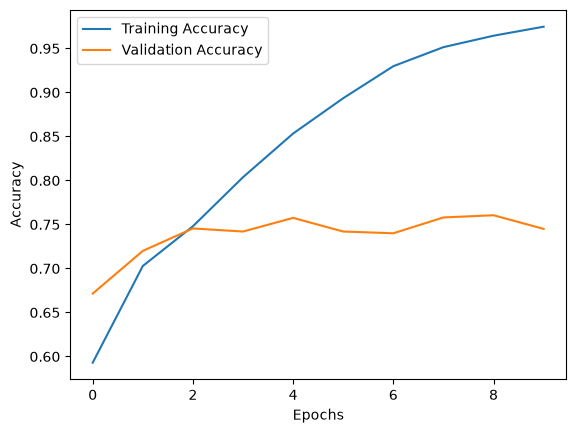

In [28]:
# Plot Accuracy
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [29]:
# Save Model
model.save("model.keras")
print("Model saved successfully!")

Model saved successfully!


In [32]:
def predict_image(img_path):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (128, 128))
    img = img.astype(np.float32) / 255.0
    img = np.expand_dims(img, axis=0)  # (1, 128, 128, 3)

    pred = model.predict(img)[0][0]
    label = "Dog" if pred > 0.5 else "Cat"
    print(f"Prediction: {label} (raw score: {pred:.4f})")

predict_image("dog.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Prediction: Dog (raw score: 0.9988)
